In [1]:
import treecorr
import numpy as np
import matplotlib.pyplot as plt
import os
from astropy.io import fits
#import fitsio
from astropy.table import Table
#import csv 
import pandas as pd
import polars as pl

try:
    plt.style.use('/home/dy9683/cosmic-shear/cosmic-shear-with-spec-z/paperfigs.mplstyle')
except Exception as e:
    print(f'Error: {e}')
    # print(f"Could not find style file paperfigs.mplstyle")

# Load Catalog

DES Y3 Matched from Jared

In [2]:
desy3 = '/scratch/gpfs/js1998/matched_catalogs/desy3_matched.csv'

In [3]:
file_path = desy3
des_catalog = pl.scan_csv(file_path).filter(pl.col('lensing_match') == 1).collect()

In [4]:
des_catalog

,TARGETID,SURVEY,PROGRAM,TILEID,LASTNIGHT,Z_BEST,Z_CONF,ZERR_BEST,ZWARN_BEST,SPECTYPE_BEST,SUBTYPE_BEST,CHI2_BEST,DELTACHI2_BEST,PETAL_LOC,FIBER,COADD_FIBERSTATUS,TARGET_RA,TARGET_DEC,DESINAME,OBJTYPE,FIBERASSIGN_X,FIBERASSIGN_Y,PRIORITY,COADD_NUMEXP,COADD_EXPTIME,COADD_NUMNIGHT,COADD_NUMTILE,MIN_MJD,MAX_MJD,MEAN_MJD,GOOD_SPEC,EFFTIME_SPEC,ZCAT_NSPEC,ZCAT_PRIMARY,SV_NSPEC,SV_PRIMARY,MAIN_NSPEC,MAIN_PRIMARY,CMX_TARGET,DESI_TARGET,BGS_TARGET,MWS_TARGET,SCND_TARGET,SV1_DESI_TARGET,SV1_BGS_TARGET,SV1_MWS_TARGET,SV1_SCND_TARGET,SV2_DESI_TARGET,SV2_BGS_TARGET,SV2_MWS_TARGET,SV2_SCND_TARGET,SV3_DESI_TARGET,SV3_BGS_TARGET,SV3_MWS_TARGET,SV3_SCND_TARGET,lensing_ra,lensing_dec,e1,e2,lensing_weight,R11,R12,R21,R22,lensing_match
i64,i64,str,str,i64,i64,f64,i64,f64,i64,str,str,f64,f64,i64,i64,i64,f64,f64,str,str,f64,f64,i64,i64,f64,i64,i64,f64,f64,f64,bool,f64,i64,bool,i64,bool,i64,bool,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64
21758,-417123489,"""b'main'""","""b'backup'""",41712,20211206,0.239844,0,0.000075,5,"""b'GALAXY'""",null,7426.66,1.5806394,3,1758,2,26.076478,-0.428429,"""b'DESI J026.0764-00.4284'""","""b'SKY'""",366.84595,123.956696,0,2,1209.8127,2,1,59544.188426,59555.153371,59549.670898,false,61.92292,1,true,0,false,1,true,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,26.076449,-0.428281,0.099498,0.139609,65.425758,0.615605,-0.076059,-0.083463,0.448733,1
23757,-417127377,"""b'main'""","""b'backup'""",41712,20211206,0.368981,0,0.000062,3,"""b'GALAXY'""",null,2173.2861,9.54121,7,3757,16777218,28.789048,-0.209906,"""b'DESI J028.7890-00.2099'""","""b'SKY'""",-317.13388,177.67732,0,2,1209.8127,2,1,59544.188426,59555.153371,59549.670898,false,60.928967,1,true,0,false,1,true,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,28.789088,-0.209878,-0.018326,-0.387063,37.127613,-0.452307,-0.114393,-0.590297,-0.317143,1
23948,-417127508,"""b'main'""","""b'backup'""",41712,20211206,1.466835,0,0.000196,2049,"""b'GALAXY'""",null,7461.828,15.550927,7,3948,1026,29.036719,-0.558798,"""b'DESI J029.0367-00.5587'""","""b'SKY'""",-381.31937,90.30272,0,2,1209.8127,2,1,59544.188426,59555.153371,59549.670898,false,73.723305,1,true,0,false,1,true,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,29.036853,-0.558574,-0.017622,-0.091004,42.92194,0.115604,0.510982,-0.527502,1.662834,1
25073,-417130303,"""b'main'""","""b'backup'""",41713,20211206,0.463411,0,0.000165,2049,"""b'GALAXY'""",null,7318.9463,10.41336,0,73,1026,29.578841,0.492053,"""b'DESI J029.5788+00.4920'""","""b'SKY'""",1.3543319,-303.97522,0,2,902.1866,2,1,59544.198052,59555.162188,59549.68012,false,190.38599,1,true,0,false,1,true,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,29.578959,0.492108,-0.226532,-0.19087,36.344944,1.418078,-0.227428,-0.15065,0.54204,1
25525,-417131483,"""b'main'""","""b'backup'""",41713,20211206,1.325744,0,0.000109,2053,"""b'GALAXY'""",null,7562.052,0.9652837,1,525,1026,28.836763,0.30236,"""b'DESI J028.8367+00.3023'""","""b'SKY'""",189.5302,-357.29422,0,2,902.1866,2,1,59544.198052,59555.162188,59549.68012,false,106.558716,1,true,0,false,1,true,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,28.836518,0.302366,-0.017202,-0.205938,63.557999,0.951655,-0.032644,-0.049083,0.82511,1
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
117342971,39627779334997596,"""b'sv1'""","""b'dark'""",80669,20210206,1.039708,3,0.000038,0,"""b'GALAXY'""",null,8940.245,199.48087,9,4971,0,38.545766,-0.287303,"""b'DESI J038.5457-00.2873'""","""b'TGT'""",-134.37021,-194.39021,3000,12,9265.851,5,1,59220.101231,59252.130438,59234.38317,true,4490.9478,2,true,1,true,0,false,0,0,0,0,0,4123168608002,0,0,0,0,0,0,0,0,0,0,0,38.545814,-0.287279,0.13866,0.048656,32.868397,-3.888363,0.901095,0.424852,1.03066,1
117342972,39627773291011665,"""b'sv1'""","""b'dark'""",80669,20210206,0.877097,3,0.000013,0,"""b'GALAXY'""",null,9404.321,945.6834,9,4972,0,38.489718,-0.525094,"""b'DESI J038.4897-00.5250'""","""b'TGT'""",-121.217575,-254.613

In [5]:
ra = des_catalog['TARGET_RA']
dec = des_catalog['TARGET_DEC']
g1 = des_catalog['e1'] 
g2 = des_catalog['e2']
z = des_catalog['Z_BEST']

# Plots

In [7]:
print(f'Number of sources: {len(des_catalog):,}')

Number of sources: 3,065,015


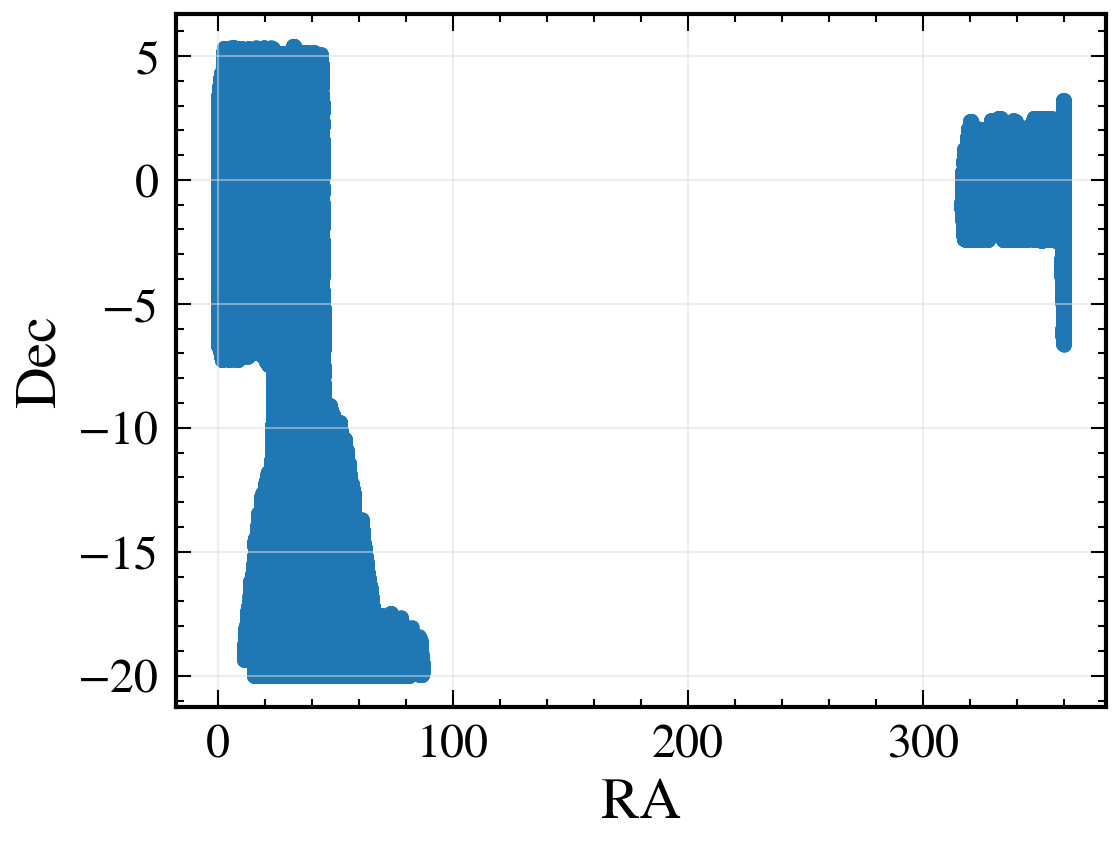

In [8]:
# ra v dec
fig, ax = plt.subplots(figsize = (8,6))
ax.scatter(ra, dec)
ax.set_xlabel("RA")
ax.set_ylabel("Dec")
#ax.set_xlim(0, 360)
#ax.set_ylim(-30, 30)
plt.show()

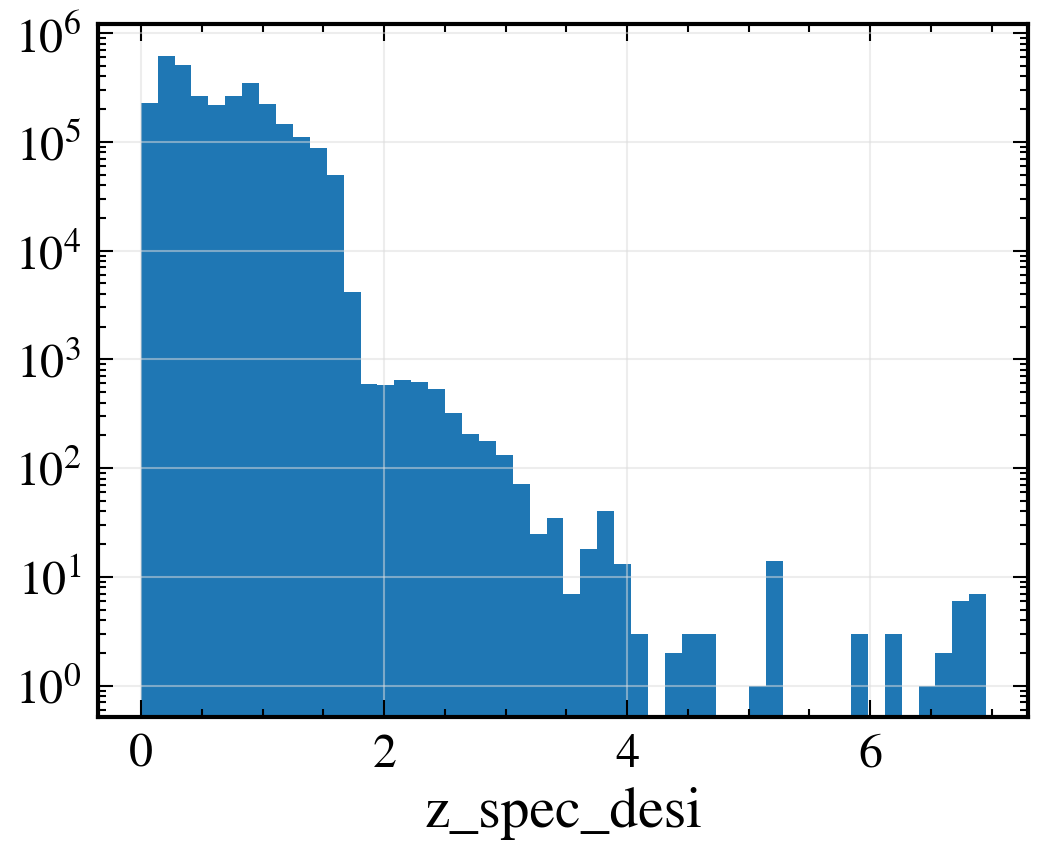

In [9]:
# histogram of redshifts
fig, ax = plt.subplots(figsize = (8,6))
ax.hist(z, bins = 50 , density = False)
ax.set_xlabel("z_spec_desi")
ax.set_yscale('log')
plt.show()

# TreeCorr Calculations

https://rmjarvis.github.io/TreeCorr/_build/html/gg.html

In [10]:
cat = treecorr.Catalog(ra=ra, dec=dec, g1=g1, g2=g2, ra_units='degrees', dec_units='degrees')
gg = treecorr.GGCorrelation(min_sep=1.0, max_sep=100.0, nbins=20, sep_units='arcmin')
gg.process(cat)

r = np.exp(gg.meanlogr)

# correlation functions
#xi_+
xip = gg.xip
# # xi_-
xim = gg.xim

#calculate variance
sig_xip = np.sqrt(gg.varxip)
sig_xim = np.sqrt(gg.varxim)

# $\xi_{+/-}$ Plot

In [11]:
xip

array([ 1.15693077e-04,  5.29561939e-05,  5.40558076e-05,  7.79961823e-07,
        2.38074780e-05,  4.15421552e-05, -5.08657109e-05,  4.99821032e-06,
       -1.58504044e-05,  1.38746829e-05,  1.04664500e-05, -2.96712608e-06,
        6.90461539e-06, -9.34777433e-07,  3.33204222e-06,  3.96278172e-06,
       -1.29561496e-06,  8.78746821e-07, -3.14092824e-07,  1.07300136e-06])

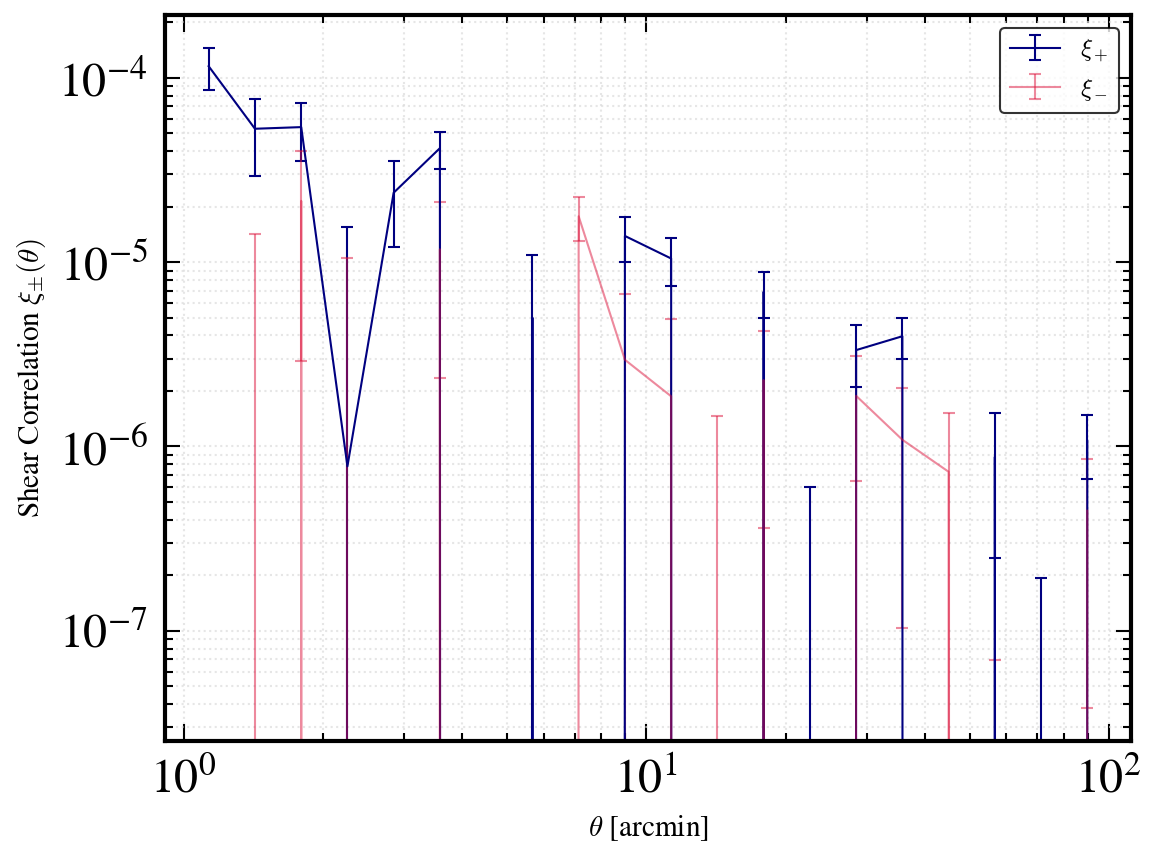

In [12]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.errorbar(r, xip, yerr=sig_xip, label=r'$\xi_+$', color='navy', capsize=3)
ax.errorbar(r, xim, yerr=sig_xim, label=r'$\xi_-$', color='crimson', capsize=3, alpha = 0.5)

ax.set_xscale('log')
ax.set_yscale('log') 
ax.set_xlabel(r'$\theta$ [arcmin]', fontsize=14)
ax.set_ylabel(r'Shear Correlation $\xi_{\pm}(\theta)$', fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, which='both', linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

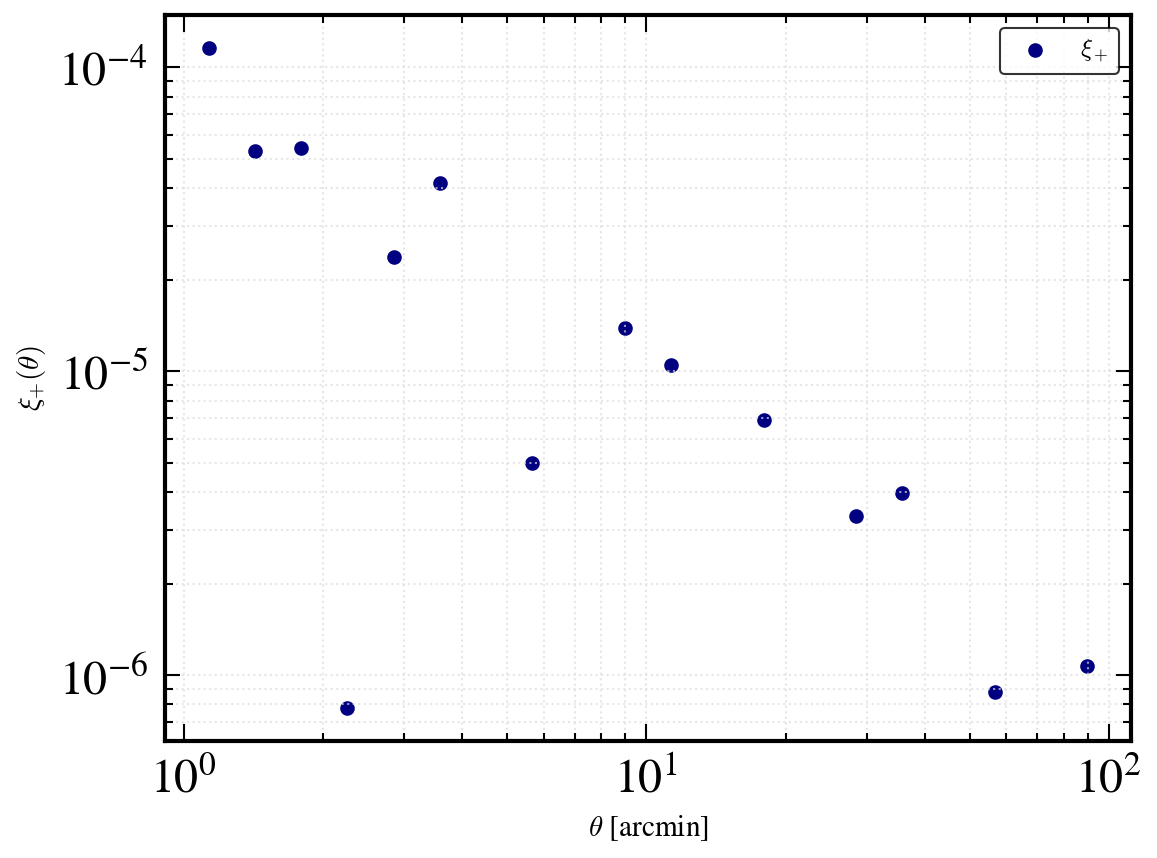

In [13]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(r, xip, label=r'$\xi_+$', color='navy')

ax.set_xscale('log')
ax.set_yscale('log') 
ax.set_xlabel(r'$\theta$ [arcmin]', fontsize=14)
ax.set_ylabel(r'$\xi_{+}(\theta)$', fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, which='both', linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()